# Implementation of Substructure Distance Splitting

Substructure Distance Splitting is one of the four suggested biased splitting methods in this project. It is *suggested* merely as an example of what is possible when we think in terms of answering a chemically meaningful question by constructing biased train test split to validate model performance.

**The question we want to answer using Substructure Distance** is `"How does the model performance change when increasing fractions of test molecules are highly dissimilar to the training molecules?"`

> *Note: This is equivalent to Activity Cliff Splitting that we constructed before. Activity Cliff can be considered a 1NN disagreement when the 1NN similarity is greter than some threshold and disagreement is greater than activity threshold.*

All the questions tend to follow the schema: "How does the model performance change when `<increasing/decreasing>` fractions of test molecules `<question>`".
We can get that answer with relative ease using the term `Bias`. Bias (bounded [0,1]) here means the fraction of test set that answers True for the given chemically meaningful question.

In [1]:
import os
import tempfile

import numpy as np
import networkx as nx
from PIL import Image

from molecularnetwork import (
    smiles_to_ecfp4_bitvect,
    compute_similarity_matrix,
    visualise_molnet_split,
)

The idea here is quite simple, what makes an adverse split ? According to me, it's the one where the test molecule is quite unlike the training molecule. Now that's very easy to write down in english but what does it really mean for a test molecule to be different enough to qualify for this ?

My attempt at answering this question has landed at the use of Tversky similarity with $\alpha = 1$ and $\beta = 0$.
The idea is quite simple, what this Tversky similarity does is it forces us to think about test molecule's shared substructure with training data. If one were to believe that test molecule with a similar substructure as that of training molecule are have higher chance of being predicted with either less error or with higher probability, then this splitting method is in many ways a logical extention of the scaffold split. This is more general that scaffold split but I'd wager that's not a bad thing. For one, clustering based on Bemis-Murcko scaffolds assumes one continuous substructure is the only seed for clustering and I think this is very pragmatic and useful for most cases. But this is not entirely true in the technical sense. One can think more abstractly about what makes compounds between two series of compounds similar, and they will come to the conclusion that this arbitrary need for one central scaffold need not be *just one* scaffold. This is very obvious because this is how we think about pharmacophores. They are arbitrary groups which are positioned in a certain manner. So, assuming this logic makes sence what we try to do here is quite simple. We first set a threshold for similarity, this basically means we think that molecules with similarity less that this threshold are considered not similar enough. Now, this means that we now simply have to fill the bias fraction of the test set with molecules that are highly related to each other but not related to molecules that will be put in train molecules. This is how effective bias is defined here. It is fraction of test set such that max tversky similarity between test molecules with any train molecule is strictly than similarity threshold.

The heuristic we use here is quite simple and something I introduced in the 01 notebook. We use connected components. These are subgraphs which are all somehow connected to each other but disconnected from the rest of the graph. Now making a test set such that there are no edges between train and test is simply a matter of placing these connected components strategically into the test set, based on the bias. 

In [2]:
UNASSIGNED_NODE = 0
TRAIN_NODE = 1
TEST_NODE = 2

This implementation follows exactly the previous desctiption. We find components, walk over them to put them in the 

In [3]:
class SubstructureDistanceSplitter:
    def __init__(self, similarity_threshold, test_fraction=0.2):
        self.similarity_threshold = similarity_threshold
        self.test_fraction = test_fraction

    def split_for_intended_bias(
        self, smiless, tversky_matrix, activity_values, intended_bias, random_seed
    ):
        if not (0.0 <= intended_bias <= 1.0):
            raise ValueError(f"intended_bias must be in [0, 1], got {intended_bias}")

        rng = np.random.default_rng(random_seed)
        n_molecules = len(smiless)
        target_test_size = int(self.test_fraction * n_molecules)
        n_isolated_test_target = int(intended_bias * target_test_size)

        components = self.find_components(tversky_matrix, self.similarity_threshold)
        assignment = self.walk_components(components, n_molecules, n_isolated_test_target, rng)

        unassigned_indices = np.where(assignment == UNASSIGNED_NODE)[0]
        n_random_fill = target_test_size - int((assignment == TEST_NODE).sum())
        if n_random_fill > 0 and len(unassigned_indices) > 0:
            n_to_sample = min(n_random_fill, len(unassigned_indices))
            random_test_indices = rng.choice(unassigned_indices, size=n_to_sample, replace=False)
            assignment[random_test_indices] = TEST_NODE

        assignment[assignment == UNASSIGNED_NODE] = TRAIN_NODE

        train_indices = np.where(assignment == TRAIN_NODE)[0]
        test_indices = np.where(assignment == TEST_NODE)[0]

        question_results = self.evaluate_substructure_question(
            test_indices, train_indices, tversky_matrix, self.similarity_threshold
        )
        effective_bias = self.effective_bias_from_question_results(question_results)

        return train_indices, test_indices, effective_bias

    def split(self, smiless, activity_values, intended_biases, n_repeats):
        fps_bitvect = [smiles_to_ecfp4_bitvect(s) for s in smiless]
        tversky_matrix = compute_similarity_matrix(fps_bitvect, method="tversky")
        for intended_bias in intended_biases:
            for repeat_index in range(n_repeats):
                train_indices, test_indices, effective_bias = self.split_for_intended_bias(
                    smiless, tversky_matrix, activity_values, intended_bias, repeat_index
                )
                yield train_indices, test_indices, effective_bias, intended_bias, repeat_index

    @staticmethod
    def find_components(tversky_matrix, similarity_threshold):
        adj_matrix = np.triu(tversky_matrix, k=1)
        adj_matrix[adj_matrix < similarity_threshold] = 0
        similarity_graph = nx.from_numpy_array(adj_matrix)
        return sorted(nx.connected_components(similarity_graph), key=len, reverse=True)

    @staticmethod
    def walk_components(components, n_molecules, n_isolated_test_target, rng):
        assignment = np.full(n_molecules, UNASSIGNED_NODE, dtype=np.int8)
        remaining_budget = n_isolated_test_target
        unused_components = list(components)
        while True:
            fitting = [c for c in unused_components if len(c) <= remaining_budget]
            if not fitting:
                break
            max_size = max(len(c) for c in fitting)
            largest = [c for c in fitting if len(c) == max_size]
            chosen = largest[int(rng.integers(len(largest)))]
            for molecule_index in chosen:
                assignment[molecule_index] = TEST_NODE
            unused_components.remove(chosen)
            remaining_budget -= len(chosen)
        return assignment

    @staticmethod
    def evaluate_substructure_question(
        test_indices, train_indices, tversky_matrix, similarity_threshold
    ):
        if len(test_indices) == 0:
            return np.array([], dtype=float)
        if len(train_indices) == 0:
            return np.ones(len(test_indices), dtype=float)
        similarity_test_vs_train = tversky_matrix[np.ix_(test_indices, train_indices)]
        max_train_similarity = similarity_test_vs_train.max(axis=1)
        is_isolated = max_train_similarity < similarity_threshold
        return is_isolated.astype(float)

    @staticmethod
    def effective_bias_from_question_results(question_results):
        if question_results.size == 0:
            return 0.0
        return float(question_results.mean())

    @staticmethod
    def build_visualization_network(smiless, activity_values, tversky_matrix, similarity_threshold):
        adj_matrix = np.triu(tversky_matrix, k=1)
        adj_matrix[adj_matrix < similarity_threshold] = 0
        G = nx.from_numpy_array(adj_matrix)
        node_attrs = {
            n: {"smiles": smi, "activity": act}
            for n, (smi, act) in enumerate(zip(smiless, activity_values))
        }
        nx.set_node_attributes(G, node_attrs)
        G.graph["activity_label"] = "activity"
        G.graph["activity_threshold"] = np.inf
        G.graph["similarity_threshold"] = similarity_threshold
        G.graph["similarity_fp"] = "2048bit ECFP4"
        G.graph["similarity_distance"] = "tversky"
        return G

    def visualise_splits(
        self, smiless, activity_values, intended_biases, n_repeats, output_path, duration=500
    ):
        fps_bitvect = [smiles_to_ecfp4_bitvect(s) for s in smiless]
        tversky_matrix = compute_similarity_matrix(fps_bitvect, method="tversky")
        G = self.build_visualization_network(
            smiless, activity_values, tversky_matrix, self.similarity_threshold
        )
        with tempfile.TemporaryDirectory() as tmpdir:
            paths = []
            frame_index = 0
            for intended_bias in intended_biases:
                for repeat_index in range(n_repeats):
                    train_idx, test_idx, effective_bias = self.split_for_intended_bias(
                        smiless, tversky_matrix, activity_values, intended_bias, repeat_index
                    )
                    p = os.path.join(tmpdir, f"frame_{frame_index:04d}.png")
                    visualise_molnet_split(
                        G, train_idx, test_idx, effective_bias, intended_bias, filepath=p, cliff=False
                    )
                    paths.append(p)
                    frame_index += 1
            frames = [Image.open(p) for p in paths]
            frames[0].save(
                output_path, save_all=True, append_images=frames[1:], duration=duration, loop=0
            )

Let's see how it looks like in action

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 

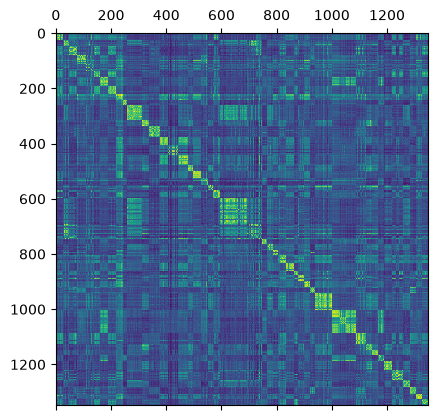

In [5]:
df = pd.read_csv("../data/standardized/target_CHEMBL325-1.IC50.csv")

smiless = df['standardized_smiles'].values
activity_values = df['pchembl_value'].values

fps = [smiles_to_ecfp4_bitvect(smiles) for smiles in smiless]
tv_sim = compute_similarity_matrix(fps, method='tversky')
tanimoto_sim = compute_similarity_matrix(fps, method='tanimoto')

plt.matshow(tv_sim)

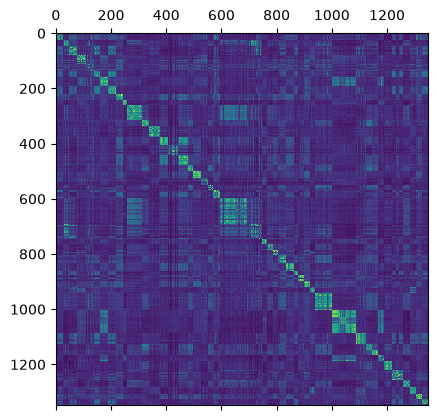

In [6]:
plt.matshow(tanimoto_sim)

In [9]:
splitter = SubstructureDistanceSplitter(similarity_threshold=0.9, test_fraction=0.2)

In [10]:
splitter.visualise_splits(df['standardized_smiles'].values, df['pchembl_value'].values, np.arange(0,1.1,0.1),n_repeats=1, output_path='similarity_dist.gif')

![](./similarity_dist.gif)